In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/spaceship-titanic/sample_submission.csv
/kaggle/input/spaceship-titanic/train.csv
/kaggle/input/spaceship-titanic/test.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_train_DS=pd.read_csv('/kaggle/input/spaceship-titanic/train.csv')
df_train_DS.shape

(8693, 14)

In [4]:
df_test_DS=pd.read_csv('/kaggle/input/spaceship-titanic/test.csv')
df_test_DS.shape

(4277, 13)

In [5]:
df_train_DS.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [6]:
df=pd.concat([df_train_DS,df_test_DS],ignore_index=True)

In [7]:
df.shape

(12970, 14)

In [8]:
df.isna().sum()

PassengerId        0
HomePlanet       288
CryoSleep        310
Cabin            299
Destination      274
Age              270
VIP              296
RoomService      263
FoodCourt        289
ShoppingMall     306
Spa              284
VRDeck           268
Name             294
Transported     4277
dtype: int64

<Axes: >

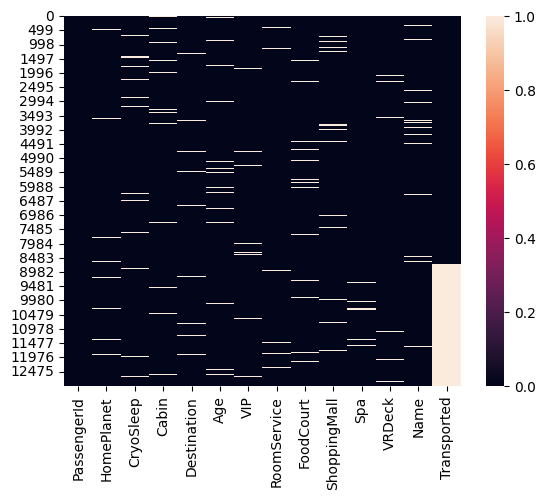

In [9]:
sns.heatmap(df.isna())

In [10]:
## lets clean the data
df['RoomService'].isna().sum()

263

In [11]:
df.shape

(12970, 14)

In [12]:
# HomePlanet-mode


In [13]:
df['Spa'].isna().sum()

284

In [14]:
df['Spa'].value_counts()

Spa
0.0       7935
1.0        218
2.0        148
3.0         82
4.0         73
          ... 
971.0        1
2290.0       1
1450.0       1
4517.0       1
1812.0       1
Name: count, Length: 1679, dtype: int64

In [15]:
df['Deck'] = df['Cabin'].str[0]
df['Side'] = df['Cabin'].str[-1]
df['Cabin_num'] = df['Cabin'].str.extract('(\d+)').astype(float)
df=df.drop(['Cabin','PassengerId','Name'],axis=1)

In [16]:

df['CryoSleep']=df['CryoSleep'].fillna(df['CryoSleep'].mode()[0]) 
df['VIP']=df['VIP'].fillna(df['VIP'].mode()[0]) 
df['Side']=df['Side'].fillna(df['Side'].mode()[0]) 

df['HomePlanet']=df['HomePlanet'].fillna(df['HomePlanet'].mode()[0]) 
df['Cabin_num']=df['Cabin_num'].fillna(df['Cabin_num'].mode()[0]) 

df['Deck']=df['Deck'].fillna(df['Deck'].mode()[0]) 

df['VRDeck']=df['VRDeck'].fillna(df['VRDeck'].mode()[0]) 

df['Spa']=df['Spa'].fillna(df['Spa'].mode()[0]) 

df['Age']=df['Age'].fillna(df['Age'].mean()) 
df['RoomService']=df['RoomService'].fillna(df['RoomService'].mean()) 
df['FoodCourt']=df['FoodCourt'].fillna(df['FoodCourt'].mean()) 
df['ShoppingMall']=df['ShoppingMall'].fillna(df['ShoppingMall'].mean()) 


# df['RoomServiceLog']=np.log1p(df['RoomService'])
# df['FoodCourtLog']=np.log1p(df['FoodCourt'])
# df['ShoppingMallLog']=np.log1p(df['ShoppingMall'])


# df=df.drop(['RoomService'],axis=1,errors='ignore')
# df=df.drop(['FoodCourtLog'],axis=1,errors='ignore')
# df=df.drop(['ShoppingMallLog'],axis=1,errors='ignore')

/tmp/ipykernel_13/3647912530.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['CryoSleep']=df['CryoSleep'].fillna(df['CryoSleep'].mode()[0])
/tmp/ipykernel_13/3647912530.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['VIP']=df['VIP'].fillna(df['VIP'].mode()[0])


In [17]:
log_features=['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']
for col in log_features:
    
    df[col+"log"]=np.log1p(df[col])

    df=df.drop([col],axis=1)


In [18]:
df['Side'].isna().sum()

0

In [19]:
df['Side'].value_counts()

Side
S    6680
P    6290
Name: count, dtype: int64

In [20]:
df.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,Transported,Deck,Side,Cabin_num,RoomServicelog,FoodCourtlog,ShoppingMalllog,Spalog,VRDecklog
0,Europa,False,TRAPPIST-1e,39.0,False,False,B,P,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
1,Earth,False,TRAPPIST-1e,24.0,False,True,F,S,0.0,4.700480,2.302585,3.258097,6.309918,3.806662
2,Europa,False,TRAPPIST-1e,58.0,True,False,A,S,0.0,3.784190,8.182280,0.000000,8.812248,3.912023
3,Europa,False,TRAPPIST-1e,33.0,False,False,A,S,0.0,0.000000,7.157735,5.918894,8.110728,5.267858
4,Earth,False,TRAPPIST-1e,16.0,False,True,F,S,1.0,5.717028,4.262680,5.023881,6.338594,1.098612


In [21]:
df['Destination'].value_counts()

Destination
TRAPPIST-1e      8871
55 Cancri e      2641
PSO J318.5-22    1184
Name: count, dtype: int64

In [22]:
df['Destination'].isna().sum()

274

In [23]:
df['Destination']=df['Destination'].fillna("MISSING")

In [24]:
# df['Des'].value_counts()

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12970 entries, 0 to 12969
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   HomePlanet       12970 non-null  object 
 1   CryoSleep        12970 non-null  bool   
 2   Destination      12970 non-null  object 
 3   Age              12970 non-null  float64
 4   VIP              12970 non-null  bool   
 5   Transported      8693 non-null   object 
 6   Deck             12970 non-null  object 
 7   Side             12970 non-null  object 
 8   Cabin_num        12970 non-null  float64
 9   RoomServicelog   12970 non-null  float64
 10  FoodCourtlog     12970 non-null  float64
 11  ShoppingMalllog  12970 non-null  float64
 12  Spalog           12970 non-null  float64
 13  VRDecklog        12970 non-null  float64
dtypes: bool(2), float64(7), object(5)
memory usage: 1.2+ MB


In [26]:
# HomePlanet,Destination, --categorical features
# ,VIP-binary


# Age-Numerical 
# RoomService,FoodCourt,ShoppingMall,Spa,VRDeck-skewed  & numercal as it bill amount
#  Cabin,Name,PassengerId-unwanted 

In [27]:
binary_cols = ['CryoSleep','VIP','Transported']

for col in binary_cols:
    df[col]=df[col].map({True:1,False:0})
    



In [28]:
df.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,Transported,Deck,Side,Cabin_num,RoomServicelog,FoodCourtlog,ShoppingMalllog,Spalog,VRDecklog
0,Europa,0,TRAPPIST-1e,39.0,0,0.0,B,P,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
1,Earth,0,TRAPPIST-1e,24.0,0,1.0,F,S,0.0,4.700480,2.302585,3.258097,6.309918,3.806662
2,Europa,0,TRAPPIST-1e,58.0,1,0.0,A,S,0.0,3.784190,8.182280,0.000000,8.812248,3.912023
3,Europa,0,TRAPPIST-1e,33.0,0,0.0,A,S,0.0,0.000000,7.157735,5.918894,8.110728,5.267858
4,Earth,0,TRAPPIST-1e,16.0,0,1.0,F,S,1.0,5.717028,4.262680,5.023881,6.338594,1.098612


In [29]:
df['VIP'].value_counts()

VIP
0    12697
1      273
Name: count, dtype: int64

In [30]:
df['VIP'].head()

0    0
1    0
2    1
3    0
4    0
Name: VIP, dtype: int64

In [31]:
df.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,Transported,Deck,Side,Cabin_num,RoomServicelog,FoodCourtlog,ShoppingMalllog,Spalog,VRDecklog
0,Europa,0,TRAPPIST-1e,39.0,0,0.0,B,P,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
1,Earth,0,TRAPPIST-1e,24.0,0,1.0,F,S,0.0,4.700480,2.302585,3.258097,6.309918,3.806662
2,Europa,0,TRAPPIST-1e,58.0,1,0.0,A,S,0.0,3.784190,8.182280,0.000000,8.812248,3.912023
3,Europa,0,TRAPPIST-1e,33.0,0,0.0,A,S,0.0,0.000000,7.157735,5.918894,8.110728,5.267858
4,Earth,0,TRAPPIST-1e,16.0,0,1.0,F,S,1.0,5.717028,4.262680,5.023881,6.338594,1.098612


<Axes: >

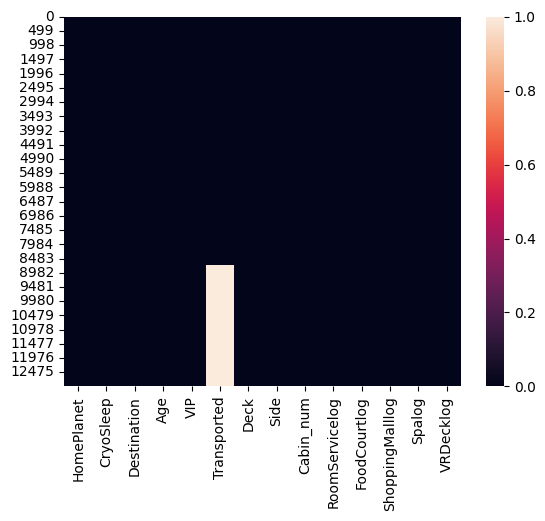

In [32]:
sns.heatmap(df.isna())